# 02 — Baseline модели
Цель: получить точку отсчёта перед экспериментами.
Сравниваем три подхода: наивный прогноз медианы, Linear Regression, KNN.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib



from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from src.preprocessing import set_seed, prepare_target, TARGET, SEED
from src.modeling import *
set_seed()

## 1. Загрузка данных

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

X_train, y_train = prepare_target(train)
X_val,   y_val   = prepare_target(val)
X_test,  y_test  = prepare_target(test)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (13003, 22) | Val: (2786, 22) | Test: (2787, 22)


In [3]:
results = []

## 2. baseline — предсказание медианы
модель: всегда предсказывать медиану трейна.
Любая нормальная модель должна бить этот результат.

In [4]:
median_pred = np.full(len(y_val), y_train.median())
results.append(evaluate('Median baseline', y_val, median_pred))

## 4. Linear Regression
Линейная регрессия — классический baseline для регрессионных задач.
Показывает, насколько задача линейно решаема.

In [5]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
lr_pipe.fit(X_train, y_train)
results.append(evaluate('Linear Regression', y_val, lr_pipe.predict(X_val)))

## 5. Ridge Regression
Линейная модель с L2-регуляризацией — устойчивее при мультиколлинеарности фич.

In [6]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=SEED)),
])
ridge_pipe.fit(X_train, y_train)
results.append(evaluate('Ridge Regression', y_val, ridge_pipe.predict(X_val)))

## 6. KNN Regressor
Непараметрическая модель — предсказывает по средней зарплате ближайших игроков.
Хороший baseline для проверки локальных паттернов.

In [7]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=10)),
])
knn_pipe.fit(X_train, y_train)
results.append(evaluate('KNN (k=10)', y_val, knn_pipe.predict(X_val)))

## 7. Сравнение моделей

In [8]:
results_df = pd.DataFrame(results).set_index('model').sort_values('rmse')
display(results_df.round(4))

,rmse,mae,r2,mape
model,,,,
Linear Regression,0.4827,0.3624,0.8652,39.5157
Ridge Regression,0.4828,0.3624,0.8651,39.5279
KNN (k=10),0.4877,0.3689,0.8624,41.5176
Median baseline,1.3158,1.0849,-0.0020,144.2404


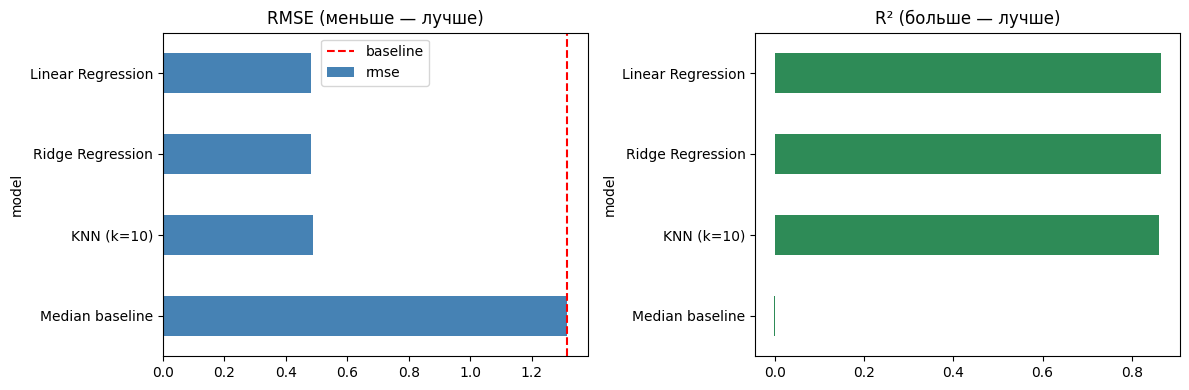

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df['rmse'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('RMSE (меньше — лучше)')
axes[0].axvline(results_df.loc['Median baseline', 'rmse'], color='red',
                linestyle='--', label='baseline')
axes[0].legend()

results_df['r2'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen'
)
axes[1].set_title('R² (больше — лучше)')

plt.tight_layout()
plt.show()

 ### Вывод
 Линейные модели и KNN снизили ошибку в 3 раза по сравнению с медианой (RMSE 1.31 → 0.48). Это доказывает высокую предсказательную силу рейтинга.

## 8. Лучшая baseline-модель на тесте

In [10]:
best_pipe = lr_pipe

print('=== Результат на TEST (финальная оценка baseline) ===')
evaluate('Linear Regression (test)', y_test, best_pipe.predict(X_test))

=== Результат на TEST (финальная оценка baseline) ===


{'model': 'Linear Regression (test)',
 'rmse': np.float64(0.47933914786512255),
 'mae': 0.3594425649739861,
 'r2': 0.8668472117686847,
 'mape': np.float64(39.217411599085544)}

## 9. Анализ остатков

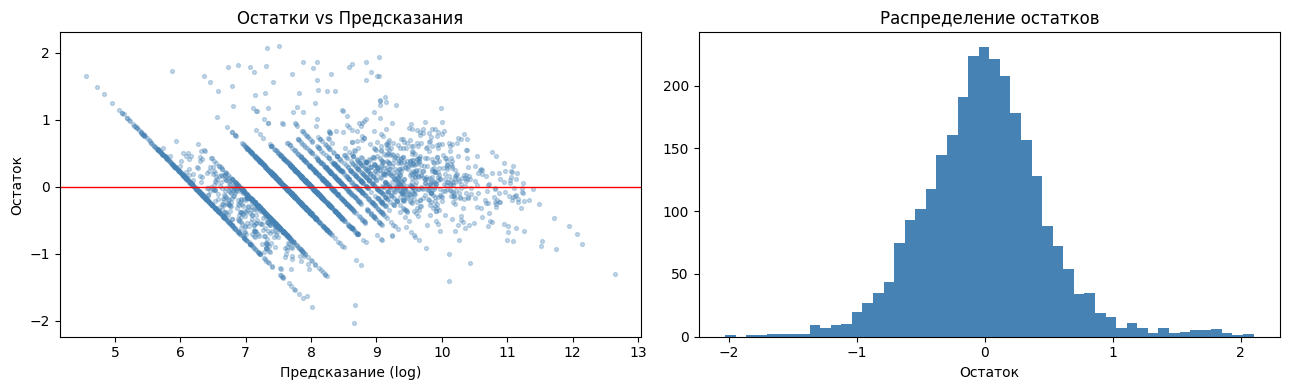

Среднее остатков: -0.0072
Std остатков:     0.4828


In [11]:
y_pred_val = ridge_pipe.predict(X_val)
residuals = y_val - y_pred_val

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_val, residuals, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Предсказание (log)')
axes[0].set_ylabel('Остаток')
axes[0].set_title('Остатки vs Предсказания')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Остаток')
axes[1].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

print(f'Среднее остатков: {residuals.mean():.4f}')
print(f'Std остатков:     {residuals.std():.4f}')

### Вывод
Ошибки распределены нормально, но их разброс выше у дешевых игроков — там в данных больше «шума». 

## 10. Важность признаков (коэффициенты Ridge)

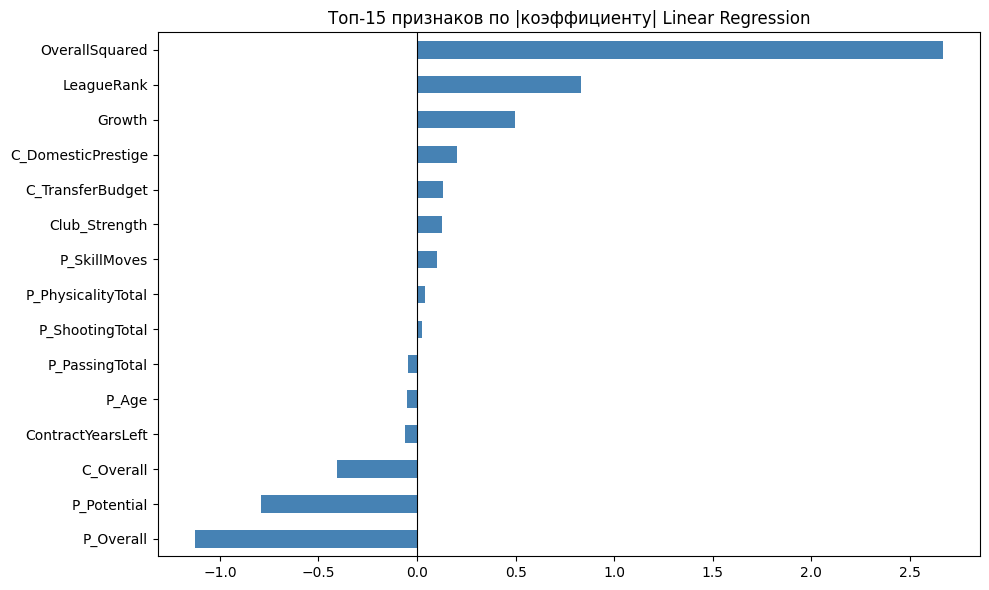

In [12]:
coefs = pd.Series(
    best_pipe.named_steps['model'].coef_,
    index=X_train.columns
).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
coefs.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Топ-15 признаков по |коэффициенту| Linear Regression')
plt.tight_layout()
plt.show()

### Вывод
OverallSquared — главный фактор. Зарплата растет не линейно, а ускоряется с каждым пунктом рейтинга. 